# Metabolomics Workbench - Data Pipeline

Please install "mwtab" library to your current working environment

In [ ]:
! pip install mwtab

## Download data from https://www.metabolomicsworkbench.org/ with REST API using mwtab

In [ ]:
! mwtab

In [ ]:
! mwtab download study all --to-path="datasets\disease_datasets\metabolomics_workbench\raw" \
                           --input-item=study_id --output-format=json --verbose

## Rename studies based on StudyID

In [ ]:
import os

RAW_WORKBENCH_PATH = os.path.join('datasets', 'disease_datasets', 'metabolomics_workbench', "raw")

for filename in os.listdir(RAW_WORKBENCH_PATH):
    if filename.endswith(".json"):
        old_name = os.path.join(RAW_WORKBENCH_PATH, filename)
        
        #print(f"{filename = }")
        result = filename.find('FST')
        #print("Substring 'FST' found at index:", result)

        formatted_name = filename[72:80] + ".json"
        #print(f"{formatted_name = }")
        new_name = os.path.join(RAW_WORKBENCH_PATH, formatted_name)

        # Renaming the file
        os.rename(old_name, new_name)
        print(f"Study {filename[72:80]} renamed as {formatted_name}.")

## Delete studies not related to human, Homo Sapiens

In [ ]:
import json
import os
import shutil

RAW_WORKBENCH_PATH = os.path.join('datasets', 'disease_datasets', 'metabolomics_workbench', "raw")
PROBLEMATIC_STUDY_PATH = os.path.join('datasets', 'disease_datasets', 'metabolomics_workbench', "problematic_json")

problematic_file = 0

for filename in os.listdir(RAW_WORKBENCH_PATH):
    if filename.endswith(".json"):
        file_path = os.path.join(RAW_WORKBENCH_PATH, filename)

        try:
            with open(os.path.join(RAW_WORKBENCH_PATH, filename)) as f:
                study = json.load(f)
                subject_type = study["SUBJECT"]["SUBJECT_TYPE"] # Human
                subject_species = study["SUBJECT"]["SUBJECT_SPECIES"] # Homo sapiens

            if subject_species != "Homo sapiens":
                os.remove(file_path)
                print(f"File {filename} removed.")
            elif subject_type != "Human":
                os.remove(file_path)
                print(f"File {filename} removed.")
            else:
                print(f"Study {filename} has {subject_type = } and {subject_species = }.")

        except json.JSONDecodeError as error: # ERROR 1
            print(f"Error parsing JSON in file {filename}: {str(error)}")
            shutil.move(file_path, os.path.join(PROBLEMATIC_STUDY_PATH, filename))
            problematic_file += 1
            continue

        except UnicodeDecodeError as error:   # ERROR 2
            print(f"Error decoding file {filename}: {str(error)}")
            shutil.move(file_path, os.path.join(PROBLEMATIC_STUDY_PATH, filename))
            problematic_file += 1
            continue

        except KeyError as error:             # ERROR 3
            print(f"Key error in file {filename}: {str(error)}")
            shutil.move(file_path, os.path.join(PROBLEMATIC_STUDY_PATH, filename))
            problematic_file += 1
            continue

print(f"There are problems in {problematic_file} files.")

## Handle problematic JSON studies

In [ ]:
import json
import os
import shutil

RAW_WORKBENCH_PATH = os.path.join('datasets', 'disease_datasets', 'metabolomics_workbench', "raw")
PROBLEMATIC_STUDY_PATH = os.path.join('datasets', 'disease_datasets', 'metabolomics_workbench', "problematic_json")


def extract_analysis_names(file_path):
    analysis_names = []

    with open(file_path, 'r') as f:
        for line in f:
            if '"ANALYSIS_ID":"' in line:
                start_index = line.find('"ANALYSIS_ID":"') + len('"ANALYSIS_ID":"')
                end_index = line.find('"', start_index)
                analysis_id = line[start_index:end_index]
                analysis_names.append(analysis_id)

    return analysis_names

def get_json_blocks(file_path):
    json_blocks = []
    start_index = None

    with open(file_path, 'r') as f:
        file_lines = f.read().split('\n')

    for i, line in enumerate(file_lines):
        if ((line == "{") and (i - 1 == -1) or (line == "{") and file_lines[i - 1] == ""):  # JSON block starts
            start_index = i

        if (line == "}") and (file_lines[i - 1] == "" and file_lines[i + 1] == ""):  # JSON block ends
            if start_index is not None:
                json_blocks.append((start_index, i + 1))  # Add indices to the list as a tuple
                start_index = None

    return json_blocks

def save_sub_json_files(file_path, json_blocks, analysis_ids):
    for idx, (start, end) in enumerate(json_blocks):
        sub_file_path = file_path.replace(".json", "")
        sub_file_path = f"{sub_file_path}_{analysis_ids[idx]}.json"

        with open(sub_file_path, 'w') as sub_file:
            with open(file_path, 'r') as main_file:
                sub_file.writelines(main_file.readlines()[start:end])

        print(f"Sub JSON file {sub_file_path} created.")

        # Move the sub-file to the RAW_WORKBENCH_PATH directory
        dest_path = os.path.join(RAW_WORKBENCH_PATH, os.path.basename(sub_file_path))
        shutil.move(sub_file_path, dest_path)
        print(f"Sub JSON file moved to {dest_path}.")


### Single study example

In [ ]:
# Example usage:
example_path = os.path.join(PROBLEMATIC_STUDY_PATH, "ST000004.json")

json_blocks_idx = get_json_blocks(example_path)
analysis_ids = extract_analysis_names(example_path)
save_sub_json_files(example_path, json_blocks_idx, analysis_ids)


### Recover bulk studies

In [ ]:
for filename in os.listdir(PROBLEMATIC_STUDY_PATH):
    if filename.endswith(".json"):
        try:
            path = os.path.join(PROBLEMATIC_STUDY_PATH, filename)
            # Get JSON blocks
            json_blocks_idx = get_json_blocks(path)
            # Extract analysis ids
            analysis_ids = extract_analysis_names(path)
            # Create new sub JSON files
            save_sub_json_files(path, json_blocks_idx, analysis_ids)

        except UnicodeDecodeError as error:
            print(f"UnicodeDecodeError in file {filename}: {str(error)}")
            continue
        except IndexError as error:
            print(f"IndexError in file {filename}: {str(error)}")
            continue
        

## Parse the verified human related studies

In [ ]:
import datetime
import json
import os
import time
from json import dumps
from timeit import default_timer as timer

import mwtab
import pandas as pd


def mwtabJsonReader(data):
    dicte = {}
    liste = []
    subjects_samples = 0
    value_filter = [0,"0","N",""," "]
    
    measurment = data['MS_METABOLITE_DATA']['Data']

    for i in range(0,len(measurment),1):
        for j2 in measurment[i].keys(): # dictionary of subjects
            # print(j2)
            if j2 != "Metabolite":
                dicte.setdefault(j2,{})

        for j in measurment[i].keys():
            if j == "Metabolite":  # measurement = {metabolite_name:name,....}
                metabol_name = measurment[i][j]  # it will always have a value since measurement first key is metabolite_name ..
                liste.append(measurment[i][j])  # list of metabolites
            else:
                for subject in dicte.keys():  #[subject_name]
                    if  measurment[i][subject] not in value_filter :
                        dicte[subject][metabol_name] =  measurment[i][subject]
                    # else:
                        # dicte[subject][metabol_name] = "0.0"
    return dicte

def checkDatabases2(data):  # Check if our used databases are used.
    # Checks which dataset we support exists in the file
    data2 = data['MS_METABOLITE_DATA']['Metabolites']
    database = []
    # keywords = ['kegg_id', 'pubchem_id', 'hmdb_id','PubChem','KEGG','PUBCHEM','HMDB']
    keywords = ['kegg_id', 'pubchem_id', 'hmdb_id','PubChem','KEGG','PUBCHEM','HMDB','PubChem ID','HMDB ID','KEGG ID','HMDB_ID','KEGG_ID','PubChem_ID']

    for i in data2[0].keys():
        if i in keywords:
            database.append(i)

    return database

def databaseProccesing2(name):
    """
    checks if we have any of our databases
    checks which database has more metabolites available
    checks which database has more metabolites available
    # if everything is ok it returns the name and data of database
    """
    temp = checkDatabases2(name)

    mapped = {}
    mapped_final = {}
    n = ""  # temp name
    l = []  # temp len
    value_filter = [0, "0", "N", "", " "]

    if len(temp) > 0:  ## checks if we have any of our databases

        data = name['MS_METABOLITE_DATA']['Metabolites']
        for i in temp:  ## i is database name
            mapped.setdefault(i, {})
            for j in range(0, len(data), 1):  ## j is index of ordered dict from mwtab file
                # print(i,j)
                if data[j][i] not in value_filter:

                    mapped[i][data[j]["Metabolite"]] = data[j][i]
        n = temp[0]
        l = mapped[n]

        for k, v in mapped.items():  ## checks which database has more metabolites available
            if len(v) > len(l):
                l = v;
                n = k
        if len(l) == 0:  ## checks which database has more metabolites available
            return 0
        else:
            mapped_final[n] = l  # if everything is ok it returns the name and data of database
            return mapped_final
    else:
        return 0

def group_avg(sample_data3, checker=1):
    """ A function to find group and labels averages for a given study
    inputs:
    - metabolites : {studyName:"study1", analysis:{"case1:{metabolites:{metabolite:value,...},label:"Label"}  },group Label:"Label"}
    - foldChanges from db
    """
    labels = {}
    labels_case = {}
    final =[]

    for k,v in sample_data3["analysis"].items():
        for metabol in v['Metabolites']:
            if metabol not in list(labels.keys()):
                labels.setdefault(metabol,[])
                labels[metabol].append( v['Metabolites'][metabol])
            else:
                labels[metabol].append( v['Metabolites'][metabol])


        if v["Label"].lower() not in labels_case:
            labels_case.setdefault(v["Label"],[])
            labels_case[v["Label"]].append(v['Metabolites'])
        else:
            labels_case[v["Label"]].append(v['Metabolites'])


    if len(list(labels_case.keys())) > 1:
        # print(labels_case)
        # print(list(labels_case.keys()))
        for key,value in labels_case.items():
            metabolites = []
            for m1 in value:
                for k2,v2  in m1.items():
                    metabolites.append([k2,v2])
            label_cases_avg = {}
            for i in metabolites:
                if i[0] not in list(label_cases_avg.keys()):
                    label_cases_avg.setdefault(i[0],[])
                    label_cases_avg[i[0]].append(i[1])
                elif i[0] in list(label_cases_avg.keys()):
                    label_cases_avg[i[0]].append(i[1])

            final.append([str(key)+" label avg",label_cases_avg])

    final.append(["Group Avg",labels])
    final_combined = average(final)
    return final_combined


def average(list_of_dicte):
    final = {}
    for case in list_of_dicte:
        result = {}
        for k,v in case[1].items():
            avg = sum(v)/len(v)
            result[k] = avg
        final[case[0]] ={"Label":case[0],"Metabolites":result}

    return final

In [ ]:
# @app.route('/workbench-json', methods =['GET','POST'])
def mw_json_study_to_csv(study_id: str):
    """ Convert raw Metabolomics Workbench, JSON study to a CSV file.\n
        Factors indicated whether the patient is healthy or not.\n
        Others columns are unmapped metabolite names.

    Args:
        study_id (str): Study file name, eg: ST000002.json

    Returns:
        A CSV file containing study DataFrame.
    """
    # SAVE PATH
    UNMAPPED_WORKBENCH_PATH = os.path.join('datasets', 'disease_datasets', 'metabolomics_workbench', "unmapped")
    # Check if the directory path exists
    if not os.path.exists(UNMAPPED_WORKBENCH_PATH):
        # Create the directory if it doesn't exist
        os.makedirs(UNMAPPED_WORKBENCH_PATH)
        print(f"The directory '{UNMAPPED_WORKBENCH_PATH}' was created.")
    print('--------------------------------------------------------------------------------')
    

    # PARSE RAW DATA
    print(f"Parsing study: {study_id}.json")
    RAW_WORKBENCH_PATH = os.path.join('datasets', 'disease_datasets', 'metabolomics_workbench', "raw")
    data = next(mwtab.read_files(os.path.join(RAW_WORKBENCH_PATH, f"{study_id}.json")))
    mapped = {}
    mapped_final = {}
    n = ""  # temp name
    l = []  # temp len
    value_filter = [0, "0", "N", "", " "]
    title = data['PROJECT']['PROJECT_TITLE']
    print(f"Study Title: {title}")
    num_groups = data["STUDY"]["NUM_GROUPS"]
    subjects = {}

    # Collecting subjects, labels
    for sub in data['SUBJECT_SAMPLE_FACTORS']:
        name = sub['Sample ID']
        if 'Factors' in sub.keys():
            label = sub['Factors'][list(sub['Factors'].keys())[0]]
            subjects[name] = label
        else:
            label = 'not_provided'
            subjects[name] = label
    # print("Subjects Factors")
    print(f"Num Groups: {num_groups}")
    print(f"Total Subjects: {len(subjects.keys())}")
    # print(subjects)
    print('--------------------------------------------------------------------------------')

    # Extract measurments for metabolites
    measurments_data = mwtabJsonReader(data)
    # print("Measurments Data")
    # print(measurments_data)
    # print('--------------------------------------------------------------------------------')

    # RECORD
    # Extract metabolite names in the existing study
    first_patient = list(measurments_data.keys())[0]
    metabolite_names = list(measurments_data[first_patient].keys())
    columns = list(measurments_data[first_patient].keys())
    columns.insert(0, "Factors")
    print(f"There are {len(metabolite_names)} metabolites.")
    # print(f"{metabolite_names = }")
    # print(f"{columns = }")

    study_df = pd.DataFrame(columns=columns)
    study_df["Factors"] = list(subjects.values())

    for index, (patient, metabolite_data) in enumerate(measurments_data.items()):
        for metabolite, value in metabolite_data.items():
            study_df[metabolite][index] = value

    csv_file_name = study_id + ".csv"
    save_path = os.path.join(UNMAPPED_WORKBENCH_PATH, csv_file_name)

    study_df.to_csv(save_path, index=False)

In [ ]:
RAW_WORKBENCH_PATH = os.path.join('datasets', 'disease_datasets', 'metabolomics_workbench', "raw")

for filename in os.listdir(RAW_WORKBENCH_PATH):
    if filename.endswith(".json"):
        trimmed_filename = filename[:-5]
        try:
            mw_json_study_to_csv(trimmed_filename)
        except KeyError as error:
            print(f"Key error in file {filename}: {str(error)}")
            continue
        except UnboundLocalError as error:
            print(f"Unobund local error in file {filename}: {str(error)}")
            continue

## Inspect Studies

In [6]:
import os

import pandas as pd

STUDY_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolomics_workbench", "02_merged_human_only", "ST000009.csv"
)

STUDY2_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolomics_workbench", "01_filtered_human_only", "ST000009_AN000023.csv"
)

STUDY3_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolomics_workbench", "01_filtered_human_only", "ST000009_AN000024.csv"
)

# Load the DataFrame
df = pd.read_csv(STUDY_PATH)
df2= pd.read_csv(STUDY2_PATH)
df3 = pd.read_csv(STUDY3_PATH)

print(f"######### DF #########")
print(df["XANTHINE"])

print(f"######### DF 2 #########")
print(df2["XANTHINE"])

print(f"######### DF 3 #########")
print(df3["XANTHINE"])


######### DF #########
0      558856.0
1      160635.0
2      991279.0
3      353708.0
4      754443.0
         ...   
109    269771.0
110    251764.0
111    733476.0
112    224320.0
113    133682.0
Name: XANTHINE, Length: 114, dtype: float64
######### DF 2 #########
0      558856.0
1           NaN
2      991279.0
3           NaN
4      754443.0
         ...   
106    705342.0
107    855761.0
108         NaN
109         NaN
110         NaN
Name: XANTHINE, Length: 111, dtype: float64
######### DF 3 #########
0      100744.0
1      160635.0
2      261667.0
3      353708.0
4      237584.0
         ...   
109    231978.0
110    355192.0
111    269771.0
112    251764.0
113    133682.0
Name: XANTHINE, Length: 114, dtype: float64


## Inspect WORKBENCH.CSV

########################## DF ##########################
There are 827 metabolites.
There are 28149 patients.
Total number of cells: 23279223.
Total number of NA values: 20010747
85.96% of DataFrame is empty.
1281    71.584039
1231    71.584039
1230    71.584039
1229    71.584039
1228    71.584039
          ...    
5228    94.558646
1318    95.284160
1317    95.284160
1316    95.284160
1315    95.284160
Length: 28149, dtype: float64


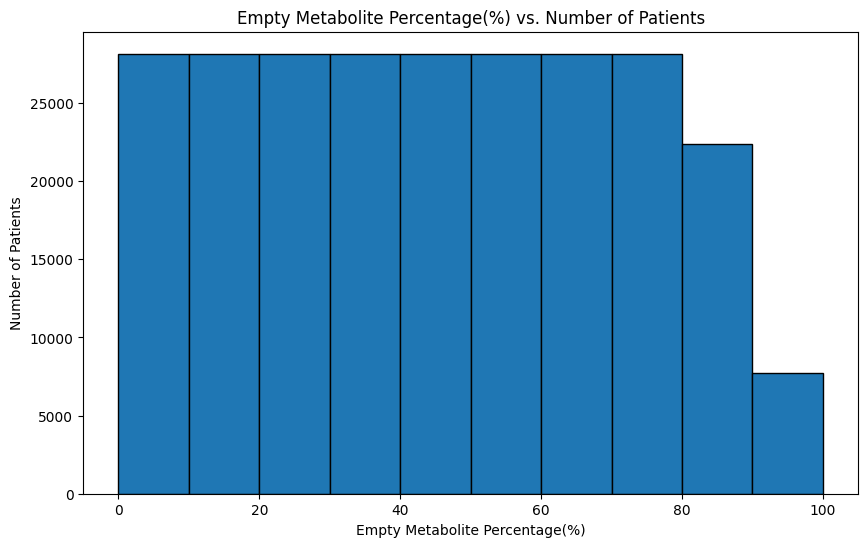

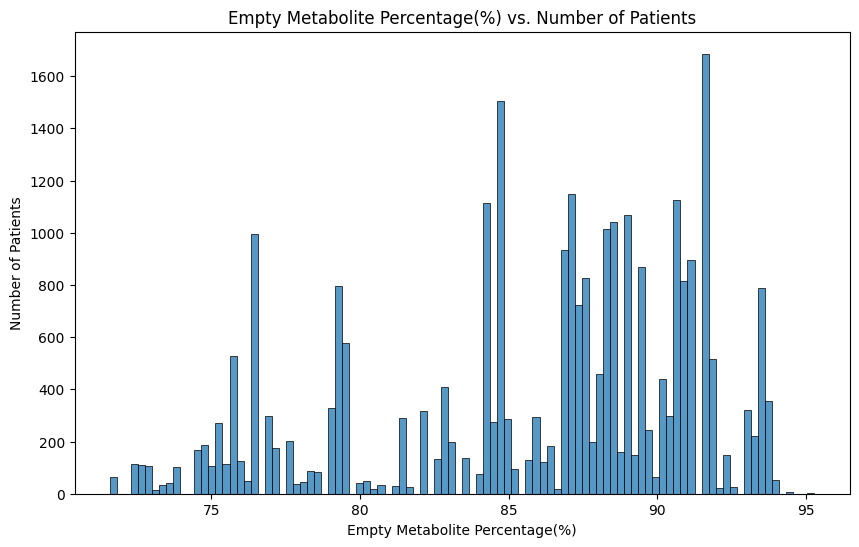

trp__L_c           6.071264
tyr__L_c           7.584639
gln__L_c           8.799602
pro__L_m          10.146009
met__L_c          10.355608
                    ...    
fprica_c          99.818821
prostgh2_c        99.818821
4mlacac_c         99.818821
debrisoquine_e    99.818821
C01041_c          99.818821
Length: 827, dtype: float64


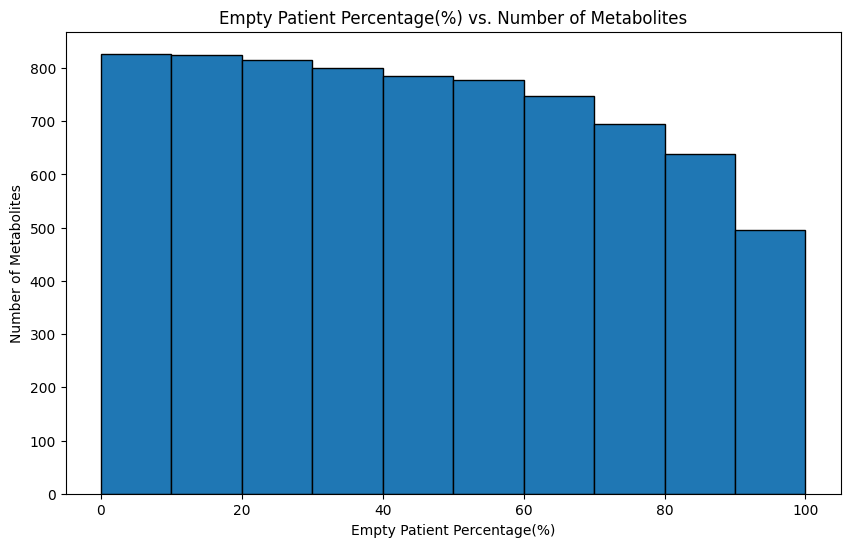

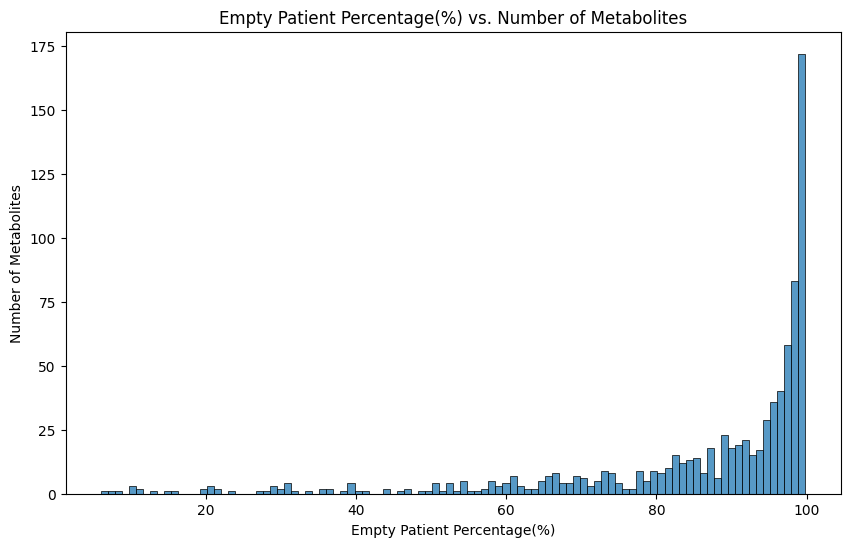

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

WORKBENCH_CSV_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolomics_workbench", "WORKBENCH.csv"
)

WORKBENCH_FILTERED_CSV_PATH = os.path.join(
    "datasets", "disease_datasets", "metabolomics_workbench", "WORKBENCH_filtered.csv"
)

# Load the DataFrame
df = pd.read_csv(WORKBENCH_FILTERED_CSV_PATH)

# Info about DataFrame
num_rows = len(df)
num_cols = len(df.columns)
num_empty = df.isna().sum().sum()
total_cells = num_rows * num_cols
empty_percent = (num_empty / total_cells) * 100

print("########################## DF ##########################")
print(f"There are {num_cols} metabolites.")
print(f"There are {num_rows} patients.")
print(f"Total number of cells: {total_cells}.")
print(f"Total number of NA values: {num_empty}")
print(f"{empty_percent:.2f}% of DataFrame is empty.")


# Plot 1:
# x: Empty Metabolite Percentage
# y: Number of patients whose metabolite sets are at least x% empty
empty_metabolite_percentages = df.isna().mean(axis=1) * 100  # Rows(patients)
empty_metabolite_percentages = empty_metabolite_percentages.sort_values()

print(empty_metabolite_percentages)

# Define the number of bins (intervals)
num_bins = 10
# Create bins
bins = np.linspace(0, 100, num_bins + 1)
# Count the number of metabolites for each interval
counts, _ = np.histogram(empty_metabolite_percentages, bins)
# Calculate the cumulative counts in reverse order
cumulative_counts = counts[::-1].cumsum()[::-1]

plt.figure(figsize=(10, 6))
plt.hist(bins[:-1], bins, weights=cumulative_counts, edgecolor='black')
plt.xlabel("Empty Metabolite Percentage(%)")
plt.ylabel("Number of Patients")
plt.title("Empty Metabolite Percentage(%) vs. Number of Patients")
# plt.xticks(bins, [f"{int(bins[i])}-{int(bins[i+1])}%" for i in range(len(bins) - 1)], rotation=45)
plt.show()


# Plot 1 - Alternative:
plt.figure(figsize=(10, 6))
sns.histplot(data=empty_metabolite_percentages, bins=100)
plt.xlabel("Empty Metabolite Percentage(%)")
plt.ylabel("Number of Patients")
plt.title("Empty Metabolite Percentage(%) vs. Number of Patients")
plt.show()


# Plot 2:
# x: Empty Patient Percentage
# y: Number of Metabolites whose patient sets are at least x% empty
empty_patient_percentages = df.isna().mean(axis=0) * 100  # Columns(metabolites)
empty_patient_percentages = empty_patient_percentages.sort_values()

print(empty_patient_percentages)

# Count the number of metabolites for each interval
metabolite_counts, _ = np.histogram(empty_patient_percentages, bins)
# Calculate the cumulative counts in reverse order
metabolite_cumulative_counts = metabolite_counts[::-1].cumsum()[::-1]

plt.figure(figsize=(10, 6))
plt.hist(bins[:-1], bins, weights=metabolite_cumulative_counts, edgecolor='black')
plt.xlabel("Empty Patient Percentage(%)")
plt.ylabel("Number of Metabolites")
plt.title("Empty Patient Percentage(%) vs. Number of Metabolites")
plt.show()


# Plot 2 - Alternative:
plt.figure(figsize=(10, 6))
sns.histplot(data=empty_patient_percentages, bins=100)
plt.xlabel("Empty Patient Percentage(%)")
plt.ylabel("Number of Metabolites")
plt.title("Empty Patient Percentage(%) vs. Number of Metabolites")
plt.show()